# Week 4 Day 3 – Reporting, Reproducibility and Final Project Preparation

## Learning objectives
- Explain why reporting and reproducibility matter in ML projects
- Structure a final project folder and report
- Fix random seeds and document environments
- Combine clustering with supervised learning responsibly
- Understand deployment and model maintenance concepts

## Section 1 — Why Reporting Matters

A strong machine learning project is not only about accuracy. It should be:

- **Understandable** for stakeholders
- **Reproducible** by teammates and future you
- **Interpretable** with clear assumptions
- **Honest** about limitations
- **Useful** for real decisions

In [1]:
import sys
import platform
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## Section 2 — Reproducible Project Structure

```text
final_project/
│
├── data/
│   ├── raw/
│   └── processed/
│
├── notebooks/
│   └── final_project_workflow.ipynb
│
├── src/
│   ├── preprocessing.py
│   ├── clustering.py
│   ├── forecasting.py
│   └── evaluation.py
│
├── figures/
│
├── reports/
│   └── final_report.md
│
├── requirements.txt
├── environment.yml
├── README.md
└── random_seed.txt
```

| Folder / file | Purpose |
|---|---|
| `data/raw` | Original downloads, never edited |
| `data/processed` | Cleaned tables used by models |
| `notebooks/` | Exploratory and teaching workflows |
| `src/` | Reusable functions (preprocessing, metrics) |
| `figures/` | Saved plots for reports |
| `reports/` | Written interpretation for graders/stakeholders |
| `requirements.txt` | Pip package list |
| `random_seed.txt` | Documented seed for replication |

## Section 3 — Reproducibility Checklist

In [2]:
import sys
import platform

import numpy as np
import pandas as pd
import matplotlib
import sklearn
import statsmodels

checklist = [
    'Code available and runnable',
    'Data source described',
    'Preprocessing documented',
    'Random seed fixed',
    'Package versions recorded',
    'Train/test split explained',
    'Metrics clearly reported',
    'Figures reproducible',
    'Limitations discussed',
    'GitHub link included',
]
for i, item in enumerate(checklist, 1):
    print(f'{i:02d}. [ ] {item}')

01. [ ] Code available and runnable
02. [ ] Data source described
03. [ ] Preprocessing documented
04. [ ] Random seed fixed
05. [ ] Package versions recorded
06. [ ] Train/test split explained
07. [ ] Metrics clearly reported
08. [ ] Figures reproducible
09. [ ] Limitations discussed
10. [ ] GitHub link included


In [3]:
from pathlib import Path

def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / "requirements.txt").exists() and (candidate / "data").exists():
            return candidate
    return cwd

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "week4"
FIGURES_DIR = REPO_ROOT / "Week_04_Unsupervised_Learning_Time_Series_and_Reporting" / "figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CUSTOMER_CSV = DATA_DIR / "week4_customer_segmentation.csv"
AIRPASSENGERS_CSV = DATA_DIR / "week4_air_passengers.csv"


In [4]:
def pkg_version(mod, name=None):
    name = name or mod.__name__
    return getattr(mod, '__version__', 'unknown')

versions = {
    'Python': sys.version.split()[0],
    'Platform': platform.platform(),
    'numpy': pkg_version(np),
    'pandas': pkg_version(pd),
    'matplotlib': pkg_version(matplotlib),
    'scikit-learn': pkg_version(sklearn),
    'statsmodels': pkg_version(statsmodels),
}
try:
    import xgboost
    versions['xgboost'] = pkg_version(xgboost)
except ImportError:
    versions['xgboost'] = 'not installed'
try:
    import torch
    versions['torch'] = pkg_version(torch)
except ImportError:
    versions['torch'] = 'not installed'

env_df = pd.DataFrame(list(versions.items()), columns=['Package', 'Version'])
display(env_df)
env_df.to_csv(DATA_DIR / 'week4_environment_versions.csv', index=False)

,Package,Version
0,Python,3.9.6
1,Platform,macOS-26.3-arm64-arm-64bit
2,numpy,1.26.4
3,pandas,2.2.3
4,matplotlib,3.9.4
5,scikit-learn,1.6.1
6,statsmodels,0.14.4
7,xgboost,not installed
8,torch,2.4.0


## Section 4 — Random Seeds and Reproducibility

Many algorithms use randomness (initialization, sampling, bagging). Without a fixed **seed**, results can change between runs.

In [5]:
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rng = np.random.default_rng(0)
X_demo = rng.normal(size=(200, 3))
y_demo = X_demo[:, 0] * 2 + rng.normal(0, 0.5, 200)

def run_without_seed():
    X_tr, X_te, y_tr, y_te = train_test_split(X_demo, y_demo, test_size=0.3)
    m = RandomForestRegressor(n_estimators=50)  # no random_state
    m.fit(X_tr, y_tr)
    return r2_score(y_te, m.predict(X_te))

unseeded = [run_without_seed() for _ in range(5)]
print('R2 without fixed seed (5 runs):', np.round(unseeded, 4))

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

def run_with_seed():
    X_tr, X_te, y_tr, y_te = train_test_split(X_demo, y_demo, test_size=0.3, random_state=SEED)
    m = RandomForestRegressor(n_estimators=50, random_state=SEED)
    m.fit(X_tr, y_tr)
    return r2_score(y_te, m.predict(X_te))

seeded = [run_with_seed() for _ in range(5)]
print('R2 with fixed seed (5 runs):', np.round(seeded, 4))

try:
    import torch
    torch.manual_seed(SEED)
    print('PyTorch seed set.')
except ImportError:
    print('PyTorch not installed — skip torch seed.')

R2 without fixed seed (5 runs): [0.9003 0.8687 0.8793 0.9077 0.8886]
R2 with fixed seed (5 runs): [0.914 0.914 0.914 0.914 0.914]
PyTorch seed set.


## Section 5 — Reporting Results Clearly

In [6]:
metrics_table = pd.DataFrame([
    {'Model': 'Seasonal Naive', 'MAE': 18.2, 'RMSE': 22.5, 'MAPE': 4.8},
    {'Model': 'SARIMA', 'MAE': 12.1, 'RMSE': 15.3, 'MAPE': 3.1},
    {'Model': 'Random Forest', 'MAE': 14.0, 'RMSE': 17.2, 'MAPE': 3.6},
])
display(metrics_table)

cluster_table = pd.DataFrame([
    {'Cluster': 0, 'Income': 'High', 'Spending': 'High', 'Visits': 'Frequent'},
    {'Cluster': 1, 'Income': 'Low', 'Spending': 'Low', 'Visits': 'Rare'},
    {'Cluster': 2, 'Income': 'Medium-High', 'Spending': 'Medium', 'Visits': 'Moderate'},
])
display(cluster_table)

,Model,MAE,RMSE,MAPE
0,Seasonal Naive,18.2,22.5,4.8
1,SARIMA,12.1,15.3,3.1
2,Random Forest,14.0,17.2,3.6


,Cluster,Income,Spending,Visits
0,0,High,High,Frequent
1,1,Low,Low,Rare
2,2,Medium-High,Medium,Moderate


### Example clustering interpretation

> The clustering analysis identified three customer groups. Cluster 0 contains high-value frequent customers, Cluster 1 contains low-frequency customers, and Cluster 2 contains moderate customers. The PCA visualization shows partial separation between clusters, but some overlap remains.

### Example forecasting interpretation

> The seasonal naive baseline achieved an RMSE of 22.5, while SARIMA achieved an RMSE of 15.3. Although SARIMA performed better, the improvement should be interpreted carefully because the test period is short.

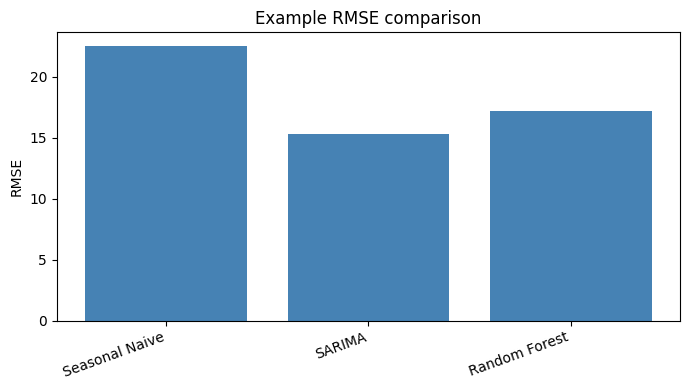

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(metrics_table['Model'], metrics_table['RMSE'], color='steelblue')
ax.set_title('Example RMSE comparison')
ax.set_ylabel('RMSE')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'day3_example_metrics_bar.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 6 — Combining Supervised and Unsupervised Workflows

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if CUSTOMER_CSV.exists():
    df = pd.read_csv(CUSTOMER_CSV)
else:
    from sklearn.datasets import make_blobs
    X_b, _ = make_blobs(n_samples=300, centers=3, random_state=42)
    df = pd.DataFrame(X_b, columns=['f1', 'f2', 'f3', 'f4'])

feat = [c for c in df.columns if c not in ['customer_value', 'kmeans_cluster']][:4]
X = df[feat].select_dtypes(include='number')
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
df['cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_sc)

rng = np.random.default_rng(42)
df['customer_value'] = X.iloc[:, 0] * 100 + df['cluster'] * 50 + rng.normal(0, 20, len(df))

y = df['customer_value']
X_base = X
X_plus = X.assign(cluster=df['cluster'])
Xb_tr, Xb_te, y_tr, y_te = train_test_split(X_base, y, test_size=0.2, random_state=42)
Xp_tr, Xp_te, _, _ = train_test_split(X_plus, y, test_size=0.2, random_state=42)

m0 = LinearRegression().fit(Xb_tr, y_tr)
m1 = LinearRegression().fit(Xp_tr, y_tr)
cmp = pd.DataFrame([
    {'Setup': 'Without cluster feature', 'MAE': mean_absolute_error(y_te, m0.predict(Xb_te)),
     'RMSE': np.sqrt(mean_squared_error(y_te, m0.predict(Xb_te))), 'R2': r2_score(y_te, m0.predict(Xb_te))},
    {'Setup': 'With cluster feature', 'MAE': mean_absolute_error(y_te, m1.predict(Xp_te)),
     'RMSE': np.sqrt(mean_squared_error(y_te, m1.predict(Xp_te))), 'R2': r2_score(y_te, m1.predict(Xp_te))},
])
display(cmp.round(3))

,Setup,MAE,RMSE,R2
0,Without cluster feature,19.106,24.432,1.0
1,With cluster feature,14.699,17.948,1.0


## Section 7 — Deployment Concept

Deployment means making a trained model **usable** by others (API, batch job, app).

- **Model artifact:** saved file (for example `.joblib`)
- **API / batch job:** receives new data, returns predictions
- **Hosting:** cloud, edge, or on-premise
- **Testing:** validate before release

In [9]:
import joblib
from sklearn.linear_model import LinearRegression

demo_X = np.array([[1.0, 2.0], [2.5, 3.1]])
demo_y = np.array([3.0, 5.0])
demo_model = LinearRegression().fit(demo_X, demo_y)

model_path = DATA_DIR / 'demo_deployment_model.joblib'
joblib.dump(demo_model, model_path)
loaded_model = joblib.load(model_path)
new_data = np.array([[1.5, 2.5]])
print('Prediction on new data:', loaded_model.predict(new_data))

Prediction on new data: [3.75144509]


## Section 8 — Model Maintenance

Models can **decay** when real-world data changes (**data drift**).

Responses: monitor metrics, inspect errors, retrain on recent data, version models, rollback if needed, respect privacy and security.

Accuracy on original-like test: 0.94


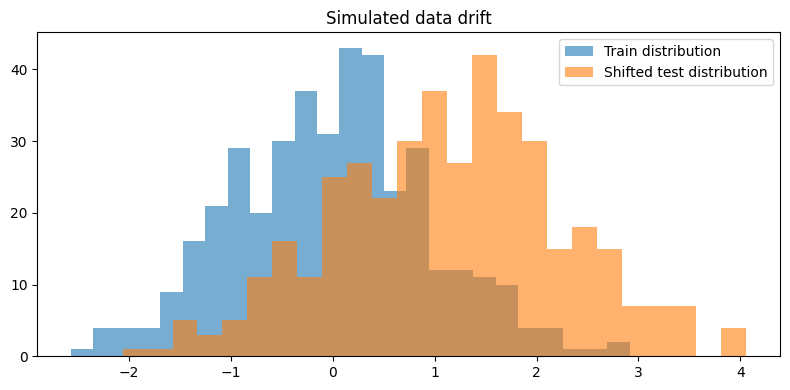

In [10]:
rng = np.random.default_rng(42)
train_x = rng.normal(0, 1, 400)
train_y = (train_x > 0).astype(int)
test_x = rng.normal(1.2, 1.1, 400)  # shifted distribution
test_y = (test_x > 0.2).astype(int)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=1000)
clf.fit(train_x.reshape(-1, 1), train_y)
print('Accuracy on original-like test:', round(accuracy_score(test_y, clf.predict(test_x.reshape(-1, 1))), 3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_x, bins=25, alpha=0.6, label='Train distribution')
ax.hist(test_x, bins=25, alpha=0.6, label='Shifted test distribution')
ax.set_title('Simulated data drift')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'day3_data_drift.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 9 — Final Project Draft Template

Copy the template below into `reports/final_report.md`.

```markdown
# Final Project Report

## 1. Problem and Dataset
Describe the problem, dataset, target variable, and goal.

## 2. Data Cleaning
Explain missing values, duplicates, outliers, and transformations.

## 3. Feature Engineering
Describe created features and why they are useful.

## 4. Clustering Method and Parameters
Explain K-Means or DBSCAN, parameter choices, and evaluation.

## 5. PCA Visualization
Show PC1/PC2 visualization and interpret cluster structure.

## 6. Time-Based Split
Explain train/test split and why random splitting was avoided.

## 7. Baseline Forecast
Describe naive, seasonal naive, or moving average baseline.

## 8. Forecasting Models
Compare at least one classical model and one ML model.

## 9. Model Comparison
Report MAE, RMSE, and other metrics.

## 10. Interpretation and Limitations
Explain results, assumptions, weaknesses, and practical meaning.

## 11. Reproducibility
Include code, random seed, package versions, environment, and GitHub link.
```

### Common mistakes / warnings
- Reporting only accuracy without context
- No seed / no `requirements.txt`
- Test set used during feature engineering
- Claiming causation from correlation or clusters

## Section 10 — Final Student Checklist

Submit:
- Notebook 4 (this week's work)
- Final project preparation draft
- Plots and metrics table
- Reproducibility information
- GitHub or code link

**Checklist**
- [ ] Clustering completed and parameters explained
- [ ] PCA visualization included
- [ ] Time-based split used for forecasting
- [ ] Baseline forecast implemented
- [ ] At least two forecasting approaches compared
- [ ] Results interpreted and limitations discussed
- [ ] Random seed fixed
- [ ] Environment documented
- [ ] Code runs top to bottom

## Mini summary
- Communicate results clearly, not only model scores.
- Organize projects so others can reproduce your work.
- Treat clustering and forecasting as parts of one decision workflow.
- Plan for deployment, monitoring, and drift after training.

In [11]:
print('Week 4 Day 3 Reporting and Final Project Preparation completed successfully.')

Week 4 Day 3 Reporting and Final Project Preparation completed successfully.
